# 12 — Get the data

Download the images we use in the rest of the workshop, and check one loads.

## Get the images

After running this command we should find a data directory in our notebooks directory which contains.

- a set of pollen images (easiest, possibly we can find all the pollen by tweaking cellpose parameters)
- a set of bee images (medium hard, probably need to do fine tuning to find only bees and not honeycomb cells)
- a set of lady bug images (hard, even after quite a bit of labelling and fine tuning hard to find them all) 

In [1]:
import urllib.request
import zipfile
from pathlib import Path

URL = 'https://www.dropbox.com/scl/fo/ock3qfwx11mvbfuih0hsc/AGk9LFOqnfm3HG_zw22vIv8?rlkey=aaoac1euyg89hpadnms96e2c9&st=4ck6sxe3&dl=1'   # must end in ?dl=1
DATA = Path('data') 
ZIP = Path('data') / 'data.zip'

# Set to True to download again and overwrite data/ -- this replaces any
# labels you have saved there with the ones in the download.
OVERWRITE = False

if OVERWRITE or not (DATA / 'bees').is_dir():
    DATA.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(URL, ZIP)

    with zipfile.ZipFile(ZIP) as z:
        z.extractall(DATA)

    # delete the archive
    ZIP.unlink()
else:
    print('data/ already downloaded; set OVERWRITE = True to download again')

print(sorted(p.name for p in DATA.iterdir() if p.is_dir()))

data/ already downloaded; set OVERWRITE = True to download again
['bees', 'ladybugs', 'pollen_count', 'stardist_cellcast']


## Load one back

Check the files are where we think they are.

(1371, 2048, 3) uint8


(np.float64(-0.5), np.float64(2047.5), np.float64(1370.5), np.float64(-0.5))

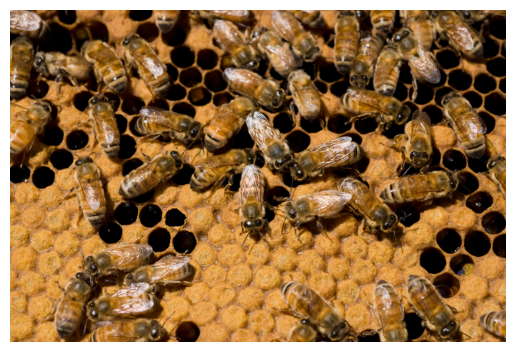

In [2]:
from skimage.io import imread
import matplotlib.pyplot as plt

img = imread(DATA / 'bees' / 'comb_03.png')
print(img.shape, img.dtype)

plt.imshow(img)
plt.axis('off')